In [33]:
import icartt # pip install icartt
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px # pip install plotly

print(f"icartt: {icartt.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

icartt: 2.0.0
pandas: 2.2.3
numpy: 2.3.5


# Data Loading Functions

In [34]:
def read_icartt_data_files(data_file_name, coord_file_name):
    """ 
    Purpose: Load the data and coordinate icartt files
    Input: data file name, coordinate file name (these files are in the same folder as the py files)
    Output: Confirmation that the files are loaded by printing data type and headers
    """

    data = icartt.Dataset(pathlib.Path(data_file_name))
    coords = icartt.Dataset(pathlib.Path(coord_file_name))
 
    print(f"Data file type: {type(data)}")
    print(f"Coordinate file type: {type(coords)}")

    # Printing the headers lets you know which VOCs are included and how their names are formatted
    print(f"Data file headers: {[x for x in data.variables]}") 
    print(f"Coordinate file headers: {[x for x in coords.variables]}")
    return data, coords

def select_VOC(VOC_name, data):
    """ 
    Purpose: Extract the desired VOC from the dataset and explore its variable properties
    Input: VOC name (as seen in the data file headers) and dataset from function 1 (read_icartt_data_files())
    Output: an array of the VOC that can be used for plotting - will also display missing data value flags, 
            data units, and data type and shape
    """
    VOC_variable_info = data.variables[VOC_name]
    select_VOC = data.data[VOC_name]
    select_VOC[select_VOC < 0] = np.nan 
    print(f"Missing data values: {VOC_variable_info.miss}") # -9999 is converted to nan automatically
    print(f"Data units: {VOC_variable_info.units}")
    print(f"VOC data type: {type(select_VOC)}")
    print(f"VOC data shape: {select_VOC.shape}")
    return select_VOC

def time_align(VOC_dict, time_data, time_coord, lat, lon):
    """
    Purpose: Time-align the VOC and coordinate datasets to prevent future alignment and shape errors
    Input: Dictionary of VOC names and corresponding arrays (from select_VOC()), time arrays from 
           the VOC and coordinate datasets, and latitude and longitude from the coordinate dataset
    Output: Dataframe that has the aligned time points and corresponding coordinates and select VOCs
    """
    VOC_data = {'Time': time_data}
    # This loop allows for inclusion of several different VOCs
    for VOC_name, VOC_array in VOC_dict.items():
        VOC_data[VOC_name] = VOC_array

    coord_data = {'Time': time_coord,
                'Latitude': lat,
                'Longitude': lon}

    VOC_df = pd.DataFrame(VOC_data)
    coord_df = pd.DataFrame(coord_data)

     # Source for pd.merge(): https://www.geeksforgeeks.org/pandas/python-pandas-merging-joining-and-concatenating
    combined_data = pd.merge(coord_df, VOC_df,  on='Time')
    print(f"Combined data layout: {combined_data.head()}")
    print(f'Combined data shape: {combined_data.shape}')
    return combined_data



# Plotting Functions

In [35]:
def plot_VOC_map(VOC_name, VOC, lat, lon):
    """
    Purpose: plot selected VOCs on corresponding coordinate points and view mixing ratio along the route
    Input: 
        VOC_name: The name of the selected VOC, as seen in the data header
        VOC: The VOC selected from the time_aligned dataframe
        lat: latitude from the coordinate file (time-aligned)
        lon: longitude from the coordinate file (time-aligned)
    Output: A map with the VOC mixing ratio plotted on top of the route coordinates
    Source: https://plotly.com/python/tile-map-layers/
    """
    plotting_df = pd.DataFrame({
        'lat': lat,
        'lon': lon,
        'VOC': VOC,
        'VOC_size': VOC
    })

    fig = px.scatter_map(plotting_df.dropna(), lat="lat", lon="lon", size="VOC", size_max=45, color="VOC") # Need dropna() so size works
    
    
    fig.update_layout(
        coloraxis_colorbar=dict(
            title=dict(
                text=f'{VOC_name} (ppb)',
                side="right"  
            ),
        )
    )
    fig.update_layout(
        map_style="white-bg",
        map_layers=[
            {
                "below": 'traces',
                "sourcetype": "raster",
                "sourceattribution": "United States Geological Survey",
                "source": [
                    "https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}"
                ]
            }
        ])

    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
    fig.update_layout(map_bounds={"west": min(lon)-0.05, "east": max(lon)+0.05, "south": min(lat)-0.05, "north": max(lat)+0.05}) # Source: https://plotly.com/python/tile-map-layers/
    fig.write_html('VOC_mixing_ratio_map.html') # Source: https://plotly.com/python/interactive-html-export/
    fig.show()
    return fig

def plot_peaks_above_baseline(VOC, VOC_name, time):
    """
    Purpose: Observe VOC spikes and plumes by viewing the time series of the data
    Input: 
        VOC_name: The name of the selected VOC, as seen in the data header
        VOC: The VOC selected from the time_aligned dataframe
        time: The time from the time_aligned dataframe
    Output: A plot of the VOC time series (mixing ratios are in log scale due to data spanning several 
            orders of magnitude) with plume points and background points differentiated by color
    """

    rolling_std = VOC.rolling(window=300).std() # Choose baseline region based on lowest rolling 5-minute standard deviation 
    baseline_end = rolling_std.idxmin() # This gives the last value in the region
    baseline_std = rolling_std.min()
    baseline_start = baseline_end - 300
    baseline_region = VOC[baseline_start:baseline_end] # Select the VOC points corresponding to the baseline region

    # Calculate the baseline mean + 3*standard deviations - for a non-normal distribution, about 90% of the data fall within this range
    # data that fall outside of this range are considered outliers or in the case of VOCs, emission events
    baseline_mean = baseline_region.mean()
    three_times_std = 3*baseline_std
    baseline_mean_with_noise = baseline_mean + three_times_std
    print(f"The baseline mean + 3σ for {VOC_name} is {baseline_mean_with_noise:.2f} ppb")

    VOC_below_baseline = VOC.copy() # Need to copy so I don't end up with an array that is entirely nans 
    VOC_below_baseline[VOC_below_baseline>baseline_mean_with_noise] = np.nan
    
    VOC_above_baseline = VOC.copy()
    VOC_above_baseline[VOC_above_baseline<=baseline_mean_with_noise] = np.nan


    date = pd.Timestamp('2024-08-03') # Change this based on the date in the file name
    time_format = pd.to_timedelta(time, unit='s')
    time_mdt = time_format - pd.Timedelta(hours=6) # UTC is 6 hours ahead of MDT
    time_clean = date + time_mdt

    plt.scatter(time_clean, VOC_above_baseline, 2, 'blue', label='Above baseline')
    plt.scatter(time_clean, VOC_below_baseline, 2, 'orange', label='Below baseline')
    plt.axhline(y = baseline_mean_with_noise, color='black', linestyle='--', label='Baseline mean + 3$\sigma$')
    plt.ylabel(f'{VOC_name} (ppb)')
    plt.xlabel('Time (MDT)')
    plt.title(f'{VOC_name} Enhancements Above Background')
    plt.yscale('log')
    plt.legend(markerscale=5)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.savefig('VOC_mixing_ratio_time_series.png', dpi = 600, bbox_inches='tight')
    plt.show()
    return ax



# Call the Functions

Data file type: <class 'icartt.dataset.Dataset'>
Coordinate file type: <class 'icartt.dataset.Dataset'>
Data file headers: ['Time_Start', 'CH3OH_NOAAPTR_ppbv', 'CH3CN_NOAAPTR_ppbv', 'CH3CHO_NOAAPTR_ppbv', 'C2H5OH_NOAAPTR_ppbv', 'CH3SH_NOAAPTR_ppbv', 'Acrolein_NOAAPTR_ppbv', 'AcetonePropanal_NOAAPTR_ppbv', 'DMS_NOAAPTR_ppbv', 'C5H8_NOAAPTR_ppbv', 'MVKMAC_NOAAPTR_ppbv', 'Benzene_NOAAPTR_ppbv', 'Toluene_NOAAPTR_ppbv', 'Styrene_NOAAPTR_ppbv', 'Benzaldehyde_NOAAPTR_ppbv', 'C8Aromatics_NOAAPTR_ppbv', 'C9Aromatics_NOAAPTR_ppbv', 'Naphthalene_NOAAPTR_ppbv', 'Octanal_NOAAPTR_ppbv', 'Monoterpenes_NOAAPTR_ppbv', 'Nonanal_NOAAPTR_ppbv', 'C7H4ClF3_NOAAPTR_ppbv', 'C10H30O5Si5_NOAAPTR_ppbv']
Coordinate file headers: ['Time_Start', 'GPS_Alt_m', 'GPS_Course_m_s', 'GPS_GndSpd_m_s', 'GPS_Heading_deg', 'GPS_Lat_deg', 'GPS_Lon_deg', 'AirTemp_C', 'RelHumidity_pct', 'Pressure_mb', 'Airmar_WindDir_deg', 'Airmar_WindSpd_m_s', 'WindDir_calc_deg', 'WindSpd_calc_m_s']
Missing data values: -9999
Data units: ppbv
V

The baseline mean + 3σ for Methanol is 11.34 ppb


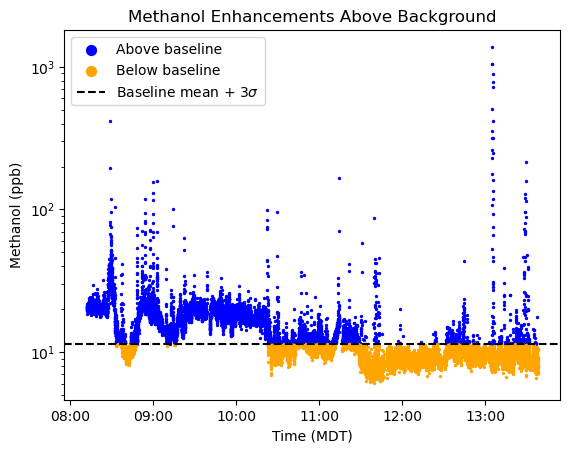

In [36]:
# Analysis setup - these inputs can be modified depending on your interests and what files you want to look at 
# USOS
data_file_name = 'USOS_PTR_MobileLab_20240803.ict'
coord_file_name = 'USOS_MetNav_MobileLab_20240803.ict'

# AEROMMA
#data_file_name = 'AEROMMA_NOAAPTR_DC8_20230822.ict'
#coord_file_name = 'AEROMMA_MetNav_DC8_20230822.ict'

def main():
    data, coords = read_icartt_data_files(data_file_name, coord_file_name)
    time_data = data.data['Time_Start']
    # Select whatever VOCs you are interested in from the dataset - here I am selecting three different hazardous air pollutants (HAPs)
    methanol = select_VOC('CH3OH_NOAAPTR_ppbv', data)
    benzene = select_VOC('Benzene_NOAAPTR_ppbv', data)
    toluene = select_VOC('Toluene_NOAAPTR_ppbv', data)

    # Get coordinates and time - naming varies between USOS and AEROMMA coordinate files
    try:
        lat = coords.data['GPS_Lat_deg']
        lon = coords.data['GPS_Lon_deg']

    except ValueError:
       try:
          lat = coords.data['Latitude']
          lon = coords.data['Longitude']
          # I had to add this mask because the AEROMMA coordinate file does not use -9999 for missing data, but -999900000
          lat[lat<-9999] = np.nan
          lon[lon<-9999] = np.nan
       except ValueError:
           return None 

    time_coord = coords.data['Time_Start']

    # Add target VOCs for time alignment with coordinate data
    target_VOCs = {
    'Methanol': methanol,
    'Benzene': benzene,
    'Toluene': toluene
    }
    combined_data = time_align(target_VOCs, time_data, time_coord, lat, lon)

    VOC_plot = combined_data.Methanol # This can be whatever VOC you want
    time_plot = combined_data.Time 
    lat_plot = combined_data.Latitude
    lon_plot = combined_data.Longitude

    # Provide the name of the VOC your are plotting for label purposes
    VOC_name = "Methanol"
    # This will generate a map with the VOC mixing ratio plotted along the measurement route
    plot_VOC_map(VOC_name, VOC_plot, lat_plot, lon_plot) 
    #
    plot_peaks_above_baseline(VOC_plot, VOC_name, time_plot)

if __name__ == "__main__":
    main()